# N31 Monte Carlo - visualization-only notebook

> **This notebook is NOT part of the development pipeline.**
> It exists ONLY to export a static figure that explains how the Layer 2 Monte Carlo simulation
> of the Strategy Orchestrator (`src/agents/strategy_orchestrator.py::_run_mc_simulation`) works.
> The figure is consumed by the TFG memoria (cap 4 sec 4.2.8.2). The runtime orchestrator does NOT
> import this notebook, does NOT depend on it, and does NOT need it to operate.

## Design

The notebook is split into small, typed, pure functions composed by two top-level entry points:

- `run_mc_simulation(scenario, n_sim, seed)` returns the full per-strategy outcomes plus the summary
  statistics, mirroring the production loop in `_run_mc_simulation` but keeping the raw arrays so we
  can plot them.
- `plot_distributions(result, scenario, output_path)` renders the four histograms, the E[S] / P10[S]
  markers and saves the PNG.

Every helper has a single responsibility, full type annotations and a short docstring, in line with
the rest of the `F1_Strat_Manager` codebase.

## What it does NOT do

- It does not patch the orchestrator code.
- It does not introduce a public API.
- It does not run any sub-agent or any LLM.
- It is not imported by anything in `src/`.

If the simulation constants in `src/agents/strategy_orchestrator.py` change, the notebook picks them
up automatically because they are imported, not hard-copied.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field
from pathlib import Path
from types import SimpleNamespace
from typing import Mapping

import numpy as np
import matplotlib.pyplot as plt

# Make the orchestrator importable so we reuse simulate_lap_window + the constants.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / '.git').exists():
    if _REPO_ROOT.parent == _REPO_ROOT:
        break
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.agents.strategy_orchestrator import (
    simulate_lap_window,
    WINDOW_LAPS,
    CFG,
)

OUTPUTS_DIR: Path = _REPO_ROOT / 'notebooks' / 'agents' / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_PATH: Path = OUTPUTS_DIR / 'n31_mc_distributions.png'

print(f'OUTPUTS_PATH = {OUTPUTS_PATH}')
print(f'WINDOW_LAPS  = {WINDOW_LAPS}')
print(f'n_sim        = {CFG.n_sim}')

c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1343.24it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.ou

OUTPUTS_PATH = c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\agents\outputs\n31_mc_distributions.png
WINDOW_LAPS  = 5
n_sim        = 500


## Dataclasses

`ScenarioInputs` collects every value the production simulation reads from the four sub-agents in
one place; `StrategySummary` mirrors the per-strategy dict returned by `_run_mc_simulation`; and
`MCResult` bundles the full distributions plus their summaries so the plot function only needs one
argument.

In [2]:
STRATEGIES: tuple[str, ...] = ('STAY_OUT', 'PIT_NOW', 'UNDERCUT', 'OVERCUT')


@dataclass(frozen=True)
class ScenarioInputs:
    """Single-lap snapshot of the values the orchestrator reads from each sub-agent."""

    title:          str
    pace_pred_s:    float
    pace_ci_p10:    float
    pace_ci_p90:    float
    cliff_p10:      float
    cliff_p50:      float
    cliff_p90:      float
    sc_prob:        float
    pit_p05:        float
    pit_p50:        float
    pit_p95:        float
    undercut_prob:  float
    alpha:          float = 0.5


@dataclass(frozen=True)
class StrategySummary:
    """Summary statistics for one strategy candidate."""

    expected: float
    p10:      float
    p90:      float
    score:    float


@dataclass
class MCResult:
    """Complete output of the Monte Carlo simulation for a given scenario."""

    outcomes:  dict[str, np.ndarray]                 = field(default_factory=dict)
    summaries: dict[str, StrategySummary]            = field(default_factory=dict)
    alpha:     float                                  = 0.5
    n_sim:     int                                    = 0

## Helpers - sampling and scoring

Three small pure functions, each one mapping one input distribution into its sample draws or one
outcome array into its summary statistics. The sampling helpers reproduce exactly the distributions
used by `_run_mc_simulation` (Normal pace, Triangular cliff and pit, Bernoulli SC and undercut).

In [3]:
def _ci_to_sigma(ci_low: float, ci_high: float) -> float:
    """Convert a 95% bootstrap CI into the equivalent Normal sigma."""
    return (ci_high - ci_low) / (2 * 1.645)


def _sample_distributions(
    scenario: ScenarioInputs,
    n_sim:    int,
    seed:     int = 42,
) -> Mapping[str, np.ndarray]:
    """Draw n_sim samples from every distribution the production loop consumes.

    Returns a dict with one array per random input: pace, cliff_laps, sc_event,
    pit_duration, undercut_success.
    """
    rng = np.random.default_rng(seed=seed)
    sigma_pace = _ci_to_sigma(scenario.pace_ci_p10, scenario.pace_ci_p90)
    return {
        'pace':              rng.normal(scenario.pace_pred_s, sigma_pace, n_sim),
        'cliff_laps':        rng.triangular(scenario.cliff_p10, scenario.cliff_p50, scenario.cliff_p90, n_sim),
        'sc_event':          rng.random(n_sim) < scenario.sc_prob,
        'pit_duration':      rng.triangular(scenario.pit_p05, scenario.pit_p50, scenario.pit_p95, n_sim),
        'undercut_success':  rng.random(n_sim) < scenario.undercut_prob,
    }


def _evaluate_strategy(strategy: str, draws: Mapping[str, np.ndarray]) -> np.ndarray:
    """Run simulate_lap_window over n_sim draws and return the position-equivalent outcomes."""
    return np.fromiter(
        (
            simulate_lap_window(
                strategy,
                cliff_i = float(draws['cliff_laps'][i]),
                sc_i    = bool(draws['sc_event'][i]),
                pit_i   = float(draws['pit_duration'][i]),
                ucut_i  = bool(draws['undercut_success'][i]),
            )
            for i in range(len(draws['cliff_laps']))
        ),
        dtype=np.float64,
    )


def _summarize_outcomes(outcomes: np.ndarray, alpha: float) -> StrategySummary:
    """Collapse an outcomes array into the standard E / P10 / P90 / score quartet."""
    expected = float(outcomes.mean())
    p10      = float(np.percentile(outcomes, 10))
    p90      = float(np.percentile(outcomes, 90))
    score    = alpha * expected + (1 - alpha) * p10
    return StrategySummary(expected=expected, p10=p10, p90=p90, score=score)

## Top-level entry point - `run_mc_simulation`

Compose the helpers above into a single call that mirrors the production loop while keeping the raw
outcomes per strategy. This is the only function the figure-rendering cell needs.

In [4]:
def run_mc_simulation(
    scenario: ScenarioInputs,
    *,
    n_sim:    int = CFG.n_sim,
    seed:     int = 42,
) -> MCResult:
    """Run the Layer 2 Monte Carlo simulation for one scenario, keeping the raw outcomes.

    Mirrors `src.agents.strategy_orchestrator._run_mc_simulation` but instead of returning only
    summary statistics, returns an `MCResult` with the full outcome array per strategy so that the
    plotting helper can render the underlying distributions.
    """
    draws    = _sample_distributions(scenario, n_sim=n_sim, seed=seed)
    outcomes: dict[str, np.ndarray]      = {}
    summary:  dict[str, StrategySummary] = {}
    for strategy in STRATEGIES:
        strategy_outcomes  = _evaluate_strategy(strategy, draws)
        outcomes[strategy] = strategy_outcomes
        summary[strategy]  = _summarize_outcomes(strategy_outcomes, scenario.alpha)
    return MCResult(
        outcomes  = outcomes,
        summaries = summary,
        alpha     = scenario.alpha,
        n_sim     = n_sim,
    )


def print_summary(result: MCResult) -> None:
    """Pretty-print the per-strategy summary statistics."""
    print(f"alpha = {result.alpha}, n_sim = {result.n_sim}")
    for strategy in STRATEGIES:
        s = result.summaries[strategy]
        print(
            f"  {strategy:<10s}  E={s.expected:+.3f}  P10={s.p10:+.3f}  "
            f"P90={s.p90:+.3f}  score={s.score:+.3f}"
        )

## Plotting helper

`plot_distributions` takes an `MCResult` plus the originating `ScenarioInputs` (for the title and
alpha) and renders the four histograms, the E[S] (solid) and P10[S] (dashed) markers and a vertical
reference at zero (the STAY_OUT baseline). Saves the PNG and returns the figure for inline display.

In [5]:
_STRATEGY_COLORS: dict[str, str] = {
    'STAY_OUT': '#4C78A8',
    'PIT_NOW':  '#F58518',
    'UNDERCUT': '#54A24B',
    'OVERCUT':  '#B279A2',
}


def _global_bins(outcomes: Mapping[str, np.ndarray], n_bins: int = 50) -> np.ndarray:
    """Return a shared bin edge array covering every strategy's outcome range."""
    flat = np.concatenate(list(outcomes.values()))
    return np.linspace(flat.min() - 0.2, flat.max() + 0.2, n_bins)


def _draw_strategy_histogram(
    ax,
    strategy:  str,
    outcomes:  np.ndarray,
    summary:   StrategySummary,
    bins:      np.ndarray,
) -> None:
    """Render one strategy's histogram plus its E and P10 vertical markers."""
    color = _STRATEGY_COLORS[strategy]
    ax.hist(
        outcomes,
        bins      = bins,
        alpha     = 0.45,
        color     = color,
        edgecolor = 'white',
        density   = True,
        label     = f'{strategy:<8s} (E={summary.expected:+.2f}, P10={summary.p10:+.2f})',
    )
    ax.axvline(summary.expected, color=color, linestyle='-',  linewidth=1.6, alpha=0.95)
    ax.axvline(summary.p10,      color=color, linestyle='--', linewidth=1.4, alpha=0.85)


def plot_distributions(
    result:      MCResult,
    scenario:    ScenarioInputs,
    output_path: Path,
) -> plt.Figure:
    """Render the four overlaid histograms with E / P10 markers and save the PNG."""
    fig, ax = plt.subplots(figsize=(10, 5.5))
    bins = _global_bins(result.outcomes)

    for strategy in STRATEGIES:
        _draw_strategy_histogram(
            ax,
            strategy = strategy,
            outcomes = result.outcomes[strategy],
            summary  = result.summaries[strategy],
            bins     = bins,
        )

    ax.axvline(0.0, color='black', linestyle=':', linewidth=1.0, alpha=0.6)
    ax.set_xlabel(f'Position-equivalent gain over W={WINDOW_LAPS} laps')
    ax.set_ylabel(f'Density ({result.n_sim} Monte Carlo draws)')
    ax.set_title(
        f'Layer 2 Monte Carlo distributions - {scenario.title} (alpha={scenario.alpha})\n'
        f'Solid line = E[S], dashed line = P10[S], dotted vertical = STAY_OUT reference'
    )
    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.25)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    return fig

## Scenario - Bahrain GP 2025, lap 22 of 57

Mid-stint pressure: cliff approaching but not imminent, low SC probability, normal pit duration,
moderately favourable undercut window. The scenario is calibrated so all four strategies produce
non-trivial, distinct distributions for didactic visibility.

In [6]:
scenario = ScenarioInputs(
    title         = 'Bahrain GP 2025, lap 22',
    pace_pred_s   = 91.5,
    pace_ci_p10   = 90.8,
    pace_ci_p90   = 92.3,
    cliff_p10     = 3.0,
    cliff_p50     = 6.0,
    cliff_p90     = 10.0,
    sc_prob       = 0.18,
    pit_p05       = 2.4,
    pit_p50       = 2.8,
    pit_p95       = 3.6,
    undercut_prob = 0.55,
    alpha         = 0.5,
)

result = run_mc_simulation(scenario)
print_summary(result)

alpha = 0.5, n_sim = 500
  STAY_OUT    E=-0.074  P10=-0.287  P90=+0.000  score=-0.180
  PIT_NOW     E=-0.158  P10=-1.344  P90=+4.239  score=-0.751
  UNDERCUT    E=+0.426  P10=-1.223  P90=+4.987  score=-0.398
  OVERCUT     E=+1.395  P10=+0.333  P90=+6.167  score=+0.864


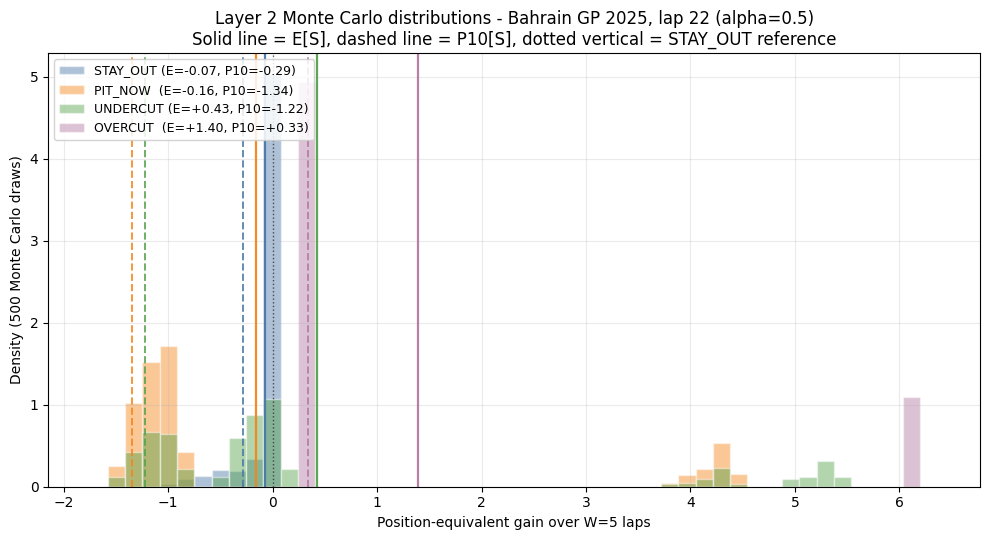

Saved figure to: c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\agents\outputs\n31_mc_distributions.png


In [7]:
fig = plot_distributions(result, scenario, output_path=OUTPUTS_PATH)
plt.show()
print(f'Saved figure to: {OUTPUTS_PATH}')

---

**Reminder.** The PNG above is meant for static export to the TFG memoria. To regenerate it, just
run all cells; nothing else in the repository depends on this notebook running successfully.
If the simulation constants in `src/agents/strategy_orchestrator.py` change, the next run picks up
the new values automatically because they are imported, not hard-copied.